# Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Загрузка и подготовка данных

In [4]:
# датасет California Housing
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")

print("Размер данных:", X.shape)
print("\nПризнаки:", list(X.columns))
X.head()

Размер данных: (20640, 8)

Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


# Разделение и нормализация

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"train: {X_train_scaled.shape[0]} объектов")
print(f"test:  {X_test_scaled.shape[0]} объектов")

train: 16512 объектов
test:  4128 объектов


# Обучение моделей БЕЗ Монте-Карло


In [8]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

# Метрики без Монте-Карло
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Результаты БЕЗ Монте-Карло \n")
print(f"Ridge Regression:      MSE = {mse_ridge:.4f},  R² = {r2_ridge:.4f}")
print(f"Gradient Boosting:     MSE = {mse_gb:.4f},  R² = {r2_gb:.4f}")

Результаты БЕЗ Монте-Карло 

Ridge Regression:      MSE = 0.5559,  R² = 0.5758
Gradient Boosting:     MSE = 0.2595,  R² = 0.8020


# Метод Монте-Карло

In [9]:
n_simulations = 50

# хранение предсказаний каждой симуляции
ridge_predictions = np.zeros((n_simulations, len(y_test)))
gb_predictions = np.zeros((n_simulations, len(y_test)))

np.random.seed(42)

for i in range(n_simulations):
    indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled[indices]
    y_boot = y_train.values[indices]

    # Ridge
    ridge_mc = Ridge(alpha=1.0)
    ridge_mc.fit(X_boot, y_boot)
    ridge_predictions[i] = ridge_mc.predict(X_test_scaled)

    # Gradient Boosting
    gb_mc = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=i
    )
    gb_mc.fit(X_boot, y_boot)
    gb_predictions[i] = gb_mc.predict(X_test_scaled)


ridge_mean = ridge_predictions.mean(axis=0)
ridge_std = ridge_predictions.std(axis=0)

gb_mean = gb_predictions.mean(axis=0)
gb_std = gb_predictions.std(axis=0)

print(f"Средняя стд предсказаний Ridge: {ridge_std.mean():.4f}")
print(f"Средняя стд предсказаний GB:    {gb_std.mean():.4f}")

Средняя стд предсказаний Ridge: 0.0186
Средняя стд предсказаний GB:    0.0909


# Оценка моделей С Монте-Карло


In [10]:
mse_ridge_mc = mean_squared_error(y_test, ridge_mean)
r2_ridge_mc = r2_score(y_test, ridge_mean)

mse_gb_mc = mean_squared_error(y_test, gb_mean)
r2_gb_mc = r2_score(y_test, gb_mean)

print("Результаты С Монте-Карло\n")
print(f"Ridge Regression:      MSE = {mse_ridge_mc:.4f},  R² = {r2_ridge_mc:.4f}")
print(f"Gradient Boosting:     MSE = {mse_gb_mc:.4f},  R² = {r2_gb_mc:.4f}")

Результаты С Монте-Карло

Ridge Regression:      MSE = 0.5556,  R² = 0.5760
Gradient Boosting:     MSE = 0.2577,  R² = 0.8034


In [12]:
comparison = pd.DataFrame({
    "Модель": ["Ridge", "Ridge (MC)", "Gradient Boosting", "Gradient Boosting (MC)"],
    "MSE": [mse_ridge, mse_ridge_mc, mse_gb, mse_gb_mc],
    "R²": [r2_ridge, r2_ridge_mc, r2_gb, r2_gb_mc]
})

print("Сравнение результатов\n")
print(comparison.to_string(index=False))

Сравнение результатов

                Модель      MSE       R²
                 Ridge 0.555855 0.575816
            Ridge (MC) 0.555635 0.575984
     Gradient Boosting 0.259496 0.801973
Gradient Boosting (MC) 0.257683 0.803357


# Визуализация предсказаний

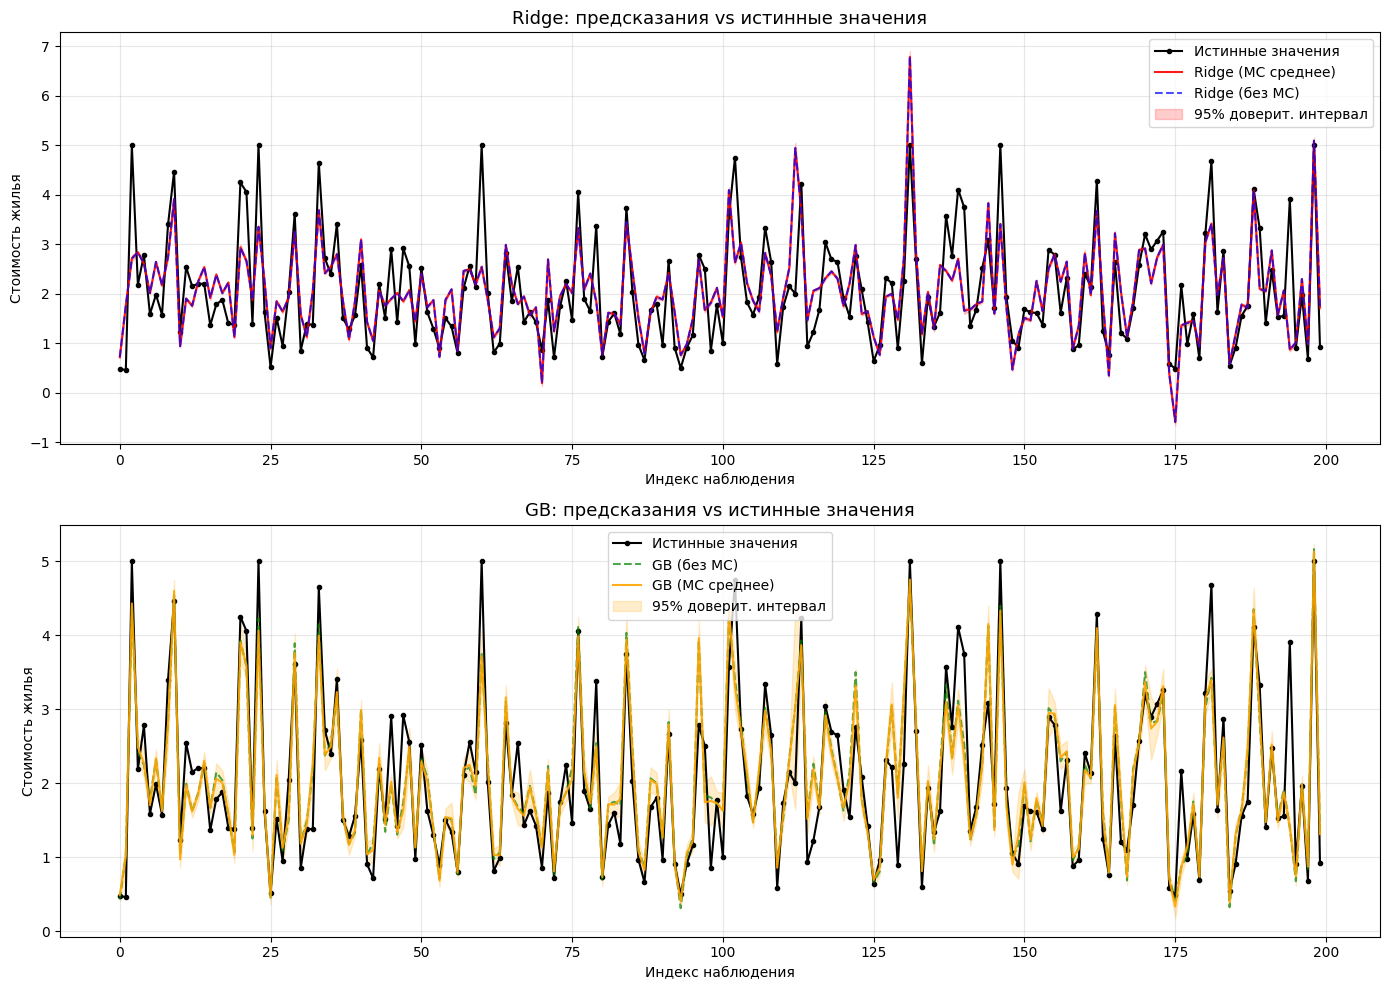

In [19]:
# первые 200 точек для наглядности
n_show = 200
idx = np.arange(n_show)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Ridge
ax = axes[0]
ax.plot(idx, y_test.values[:n_show], 'ko-', label='Истинные значения', markersize=3)
ax.plot(idx, ridge_mean[:n_show], 'r-', label='Ridge (MC среднее)', alpha=0.9)
ax.plot(idx, y_pred_ridge[:n_show], 'b--', label='Ridge (без MC)', alpha=0.7)
ax.fill_between(
    idx,
    ridge_mean[:n_show] - 2 * ridge_std[:n_show],
    ridge_mean[:n_show] + 2 * ridge_std[:n_show],
    alpha=0.2, color='red', label='95% доверит. интервал'
)
ax.set_title('Ridge: предсказания vs истинные значения', fontsize=13)
ax.set_xlabel('Индекс наблюдения')
ax.set_ylabel('Стоимость жилья')
ax.legend()
ax.grid(True, alpha=0.3)

# Gradient Boosting
ax = axes[1]
ax.plot(idx, y_test.values[:n_show], 'ko-', label='Истинные значения', markersize=3)
ax.plot(idx, y_pred_gb[:n_show], 'g--', label='GB (без MC)', alpha=0.7)
ax.plot(idx, gb_mean[:n_show], 'orange', label='GB (MC среднее)', alpha=0.9)
ax.fill_between(
    idx,
    gb_mean[:n_show] - 2 * gb_std[:n_show],
    gb_mean[:n_show] + 2 * gb_std[:n_show],
    alpha=0.2, color='orange', label='95% доверит. интервал'
)
ax.set_title('GB: предсказания vs истинные значения', fontsize=13)
ax.set_xlabel('Индекс наблюдения')
ax.set_ylabel('Стоимость жилья')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Доверительные интервалы

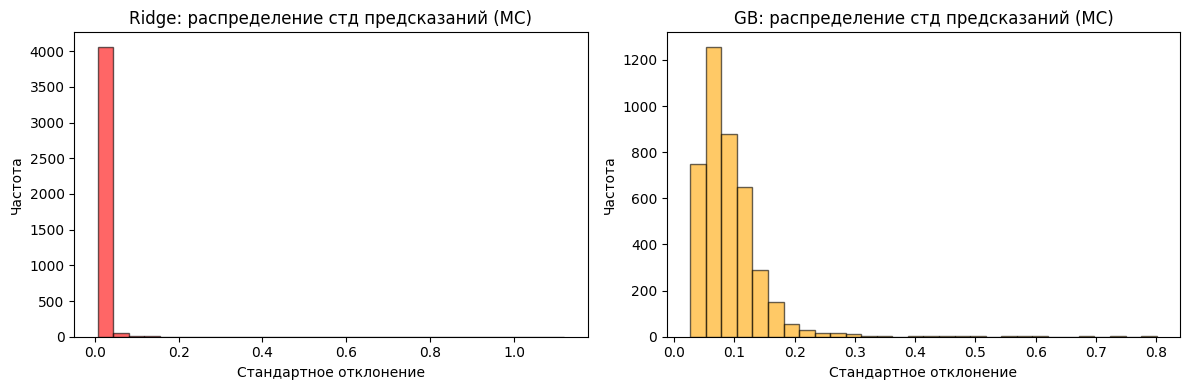

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ridge_std, bins=30, color='red', alpha=0.6, edgecolor='black')
axes[0].set_title('Ridge: распределение стд предсказаний (MC)')
axes[0].set_xlabel('Стандартное отклонение')
axes[0].set_ylabel('Частота')

axes[1].hist(gb_std, bins=30, color='orange', alpha=0.6, edgecolor='black')
axes[1].set_title('GB: распределение стд предсказаний (MC)')
axes[1].set_xlabel('Стандартное отклонение')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Вывод

1. Качество:
    Gradient Boosting значительно превосходит Ridge Regression
    по обеим метрикам (ниже MSE, выше R²).

    Это ожидаемо, так как GB ансамблевая модель, способная
    улавливать нелинейные зависимости в отличие от Ridge.

2. Влияние Монте-Карло:
    Усреднение предсказаний по bootstrap-выборкам
    незначительно улучшает метрики обеих моделей за счёт сглаживания
    случайного шума при обучении.

3. Стабильность:
    Ridge имеет меньший разброс (стд) предсказаний между
    симуляциями, то есть модель стабильнее, но менее точна.

    GB имеет больший разброс, но при усреднении даёт лучший
    результат.
